# Project: Investigate a Dataset - No-Show Appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

In [2]:
!pip install seaborn

<a id='intro'></a>
# 1. Introduction

This dataset contains information on more than 110,000 medical appointments in Brazil and focuses on whether patients attended their scheduled appointments.

The objective of this analysis is to identify factors associated with appointment attendance and determine which variables may help explain no-show behavior.

During the analysis i found and arise two fundamental questions: 

- What are the features that are correlated with the fact that pacients didnt show to their appointment

- How do you explain the fact that sending sms to pacients seems anticorrelated with no-show appointment

Other variables seems not significantly correlated with no-show appointment


## 1.1 Dataset Description


The dataset includes demographic information, medical conditions, appointment scheduling details, appointment reminders, and location information.


- Table Columns

1. PatientId
2. AppointmentID
3. Gender
4. ScheduledDay
5. AppointmentDay
6. Age
7. Neighbourhood
8. Scholarship
9. Hipertension
10. Diabetes
11. Alcoholism
12. Handcap
13. SMS_received
14. No-show

## 1.2 Research Question

1. What factors are important for us to know in order to predict whether a patient will attend or miss a scheduled medical appointment?

2. How do you explain the fact that sending sms to pacients seems anticorrelated with no-show appointment

In [3]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html


<a id='wrangling'></a>
# 2. Data Wrangling
The dataset was loaded into a Pandas DataFrame for inspection and analysis.

## 2.1 Data Loading

In [5]:
#Load dataset
df = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')

## 2.2 General Properties

In [6]:
df.shape

(110527, 14)

In [7]:
df.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [9]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


### Initial Observations

The dataset contains 110,527 observations and 14 original variables.

Most variables appear complete, with no immediately visible missing values. Initial inspection also revealed potential data quality issues, including an invalid age value (-1), date variables stored as objects, and a handcap variable with multiple "categories" not found in kaggle documentation, that are possible an error. 

## 2.3 Data Quality Assessment

The dataset was examined for missing values, duplicated records, incorrect data types, and unusual values.

In [10]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [11]:
df.nunique()

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

In [12]:
df.dtypes

PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object

In [13]:
df[df.duplicated(subset=['PatientId', 'AppointmentID'], keep=False)]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show


#### There is no duplicated patients/appointments

## 2.4 Variable Inspection

#### Age
#### Before we saw that there were negative values on age

In [14]:
df[df["Age"] == -1]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


#### Gender

In [15]:
df["Gender"].value_counts()

Gender
F    71840
M    38687
Name: count, dtype: int64

#### More F than M

#### Handcap

In [16]:
df["Handcap"].value_counts().sort_index()

Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

### Handicap Variable

According to the dataset documentation, Handcap is described as a Boolean variable. However, inspection revealed values ranging from 0 to 4.

Because multiple categories are present, the variable was treated as an ordinal categorical feature rather than a binary indicator.

### Exploratory inspection revealed several issues:

- Age contains one invalid value (-1).
- Handcap contains values from 0 to 4 despite being documented as a Boolean variable.
- Identifier and date columns require datatype conversion.
- No-show stored as object



## 2.5 Data Cleaning

Based on the issues identified during inspection, several cleaning and transformation steps were performed.
 

### Cleaning Plan

The following issues were identified during the assessment phase:

- Date variables stored as objects.
- An invalid age value (-1).
- Identifier columns stored using inappropriate numeric formats as date, Id's, no-show (object).
- The need for a simplified hancap indicator.
- The No-show target stored as text labels.

These issues were addressed before beginning the exploratory analysis.

#### Target Variable Encoding

In [17]:
df["missed_appointment"] = df["No-show"].map({
    "No": 0,
    "Yes": 1
})

#### The original categorical No-show variable was converted into a binary target variable named missed_appointment and the original column was removed.

In [18]:
df.drop(columns=["No-show"], inplace=True)

#### Date data type conversion 

In [19]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] =  pd.to_datetime(df['AppointmentDay'])


#### Invalid Age Removal

In [20]:
df = df[df['Age'] != -1]

#### Patiend id must be converted to str

In [21]:
df['PatientId'] = df['PatientId'].astype(str)
df["AppointmentID"] = df["AppointmentID"].astype(str)

#### Map Hancap to binary

In [22]:
df["HasHandicap"] = (df["Handcap"] > 0).astype(int)

## 2.6 Post-Cleaning Verification

The dataset was inspected again after cleaning to confirm that the transformations were applied correctly.

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   PatientId           110526 non-null  str                
 1   AppointmentID       110526 non-null  str                
 2   Gender              110526 non-null  str                
 3   ScheduledDay        110526 non-null  datetime64[us, UTC]
 4   AppointmentDay      110526 non-null  datetime64[us, UTC]
 5   Age                 110526 non-null  int64              
 6   Neighbourhood       110526 non-null  str                
 7   Scholarship         110526 non-null  int64              
 8   Hipertension        110526 non-null  int64              
 9   Diabetes            110526 non-null  int64              
 10  Alcoholism          110526 non-null  int64              
 11  Handcap             110526 non-null  int64              
 12  SMS_received        110526 non-n

In [24]:
df.describe()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,missed_appointment,HasHandicap
count,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029,0.201934,0.020276
std,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874,0.401445,0.140943
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000


In [25]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,missed_appointment,HasHandicap
0,29872499824296.0,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0
1,558997776694438.0,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0
2,4262962299951.0,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0
3,867951213174.0,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0
4,8841186448183.0,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0


### Cleaning Summary

The following preprocessing steps were performed:

- Converted ScheduledDay and AppointmentDay to datetime format.
- Converted PatientId and AppointmentID to string data type.
- Encoded the No-show variable into a binary target variable named missed_appointment.
- Removed the single invalid age value (-1).
- Created the HasHandicap feature to identify patients with any recorded disability.
- Verified that all transformations were applied successfully.

### Verification Results

The cleaning steps were successfully applied. Date variables were converted to datetime format, identifier columns were converted to string type, the invalid age observation was removed, and the target variable was encoded as a binary indicator suitable for analysis.

<a id='eda'></a>
# 3. Exploratory Data Analysis

This section investigates factors that may be associated with missed medical appointments.

Two main research questions are explored:


## 3.1 Overall Attendance Rate

In [26]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,missed_appointment,HasHandicap
count,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029,0.201934,0.020276
std,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874,0.401445,0.140943
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
95%,75.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000


#### A general view of all distributions: First sight

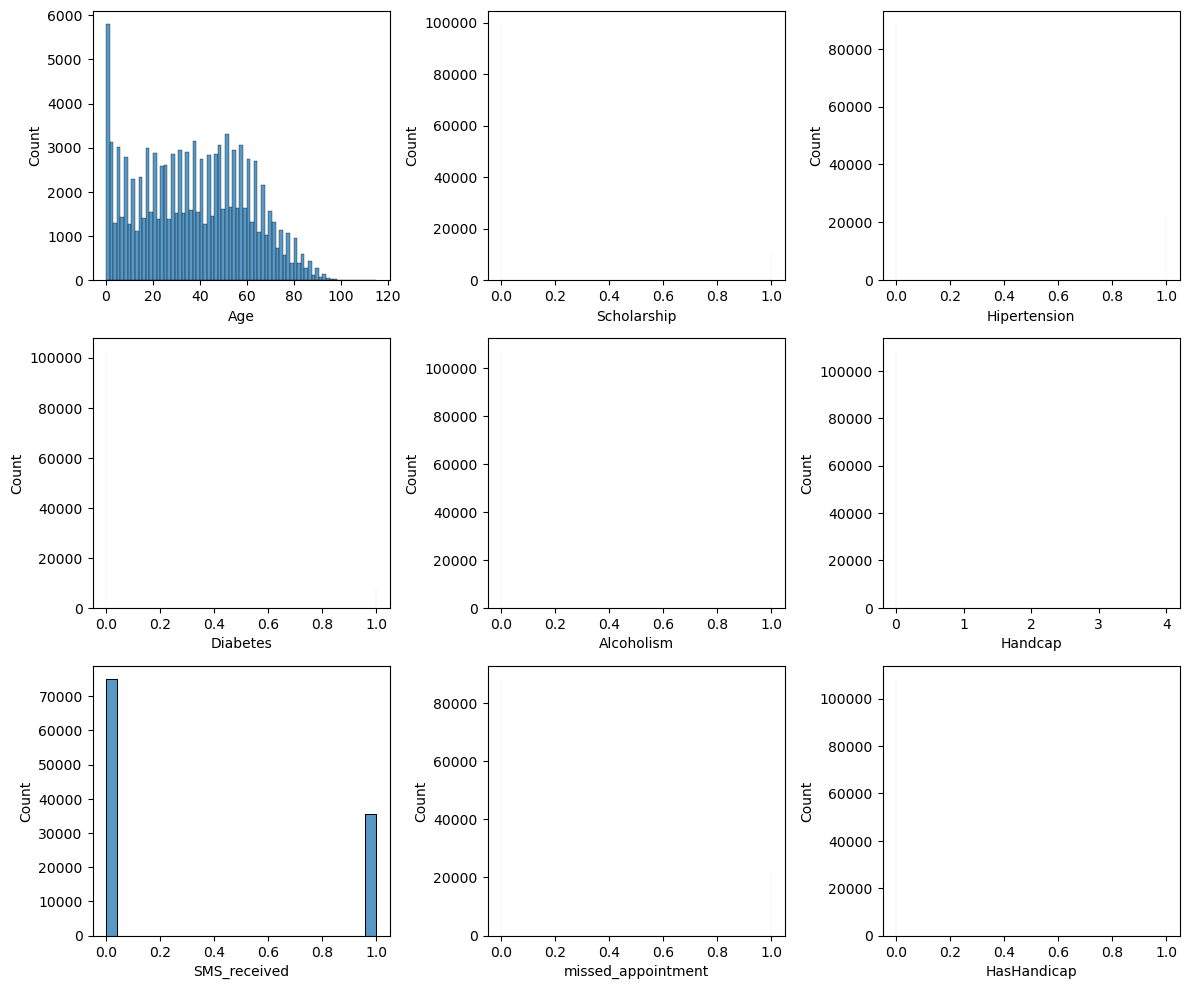

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(12,10))

cols = [
    "Age",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "missed_appointment",
    "HasHandicap"
]

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], ax=ax)

plt.tight_layout()

#### define a function to calculate no_show stats count, sum and mean

In [28]:
def calculate_no_show_stats(df, column):

    return (
        df.groupby(column)
          .agg(
              appointments=("missed_appointment", "count"),
              missed=("missed_appointment", "sum"),
              missed_rate=("missed_appointment", "mean")
          )
           .sort_values("missed_rate", ascending=False)
    )

## 3.2 Research Questions:

### Which patient features appear to be associated with missed appointments?



### 3.2.1 Age

#### Age and Appointment Attendance

Age was examined to determine whether younger or older patients are more likely to miss appointments.

In [29]:
df.groupby("missed_appointment")["Age"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

,count,mean,std,min,25%,50%,75%,95%,max
missed_appointment,,,,,,,,,
0,88207.0,37.790504,23.338645,0.0,18.0,38.0,56.0,76.0,115.0
1,22319.0,34.317667,21.965941,0.0,16.0,33.0,51.0,73.0,115.0


#### Histogram of age distribution

<Axes: >

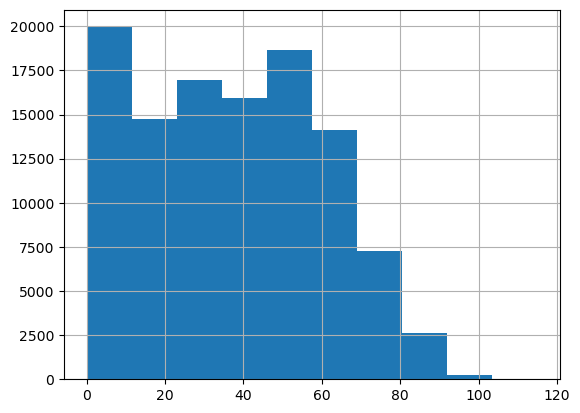

In [30]:
df["Age"].hist()

#### Boxplot for age outliers

<Axes: xlabel='missed_appointment', ylabel='Age'>

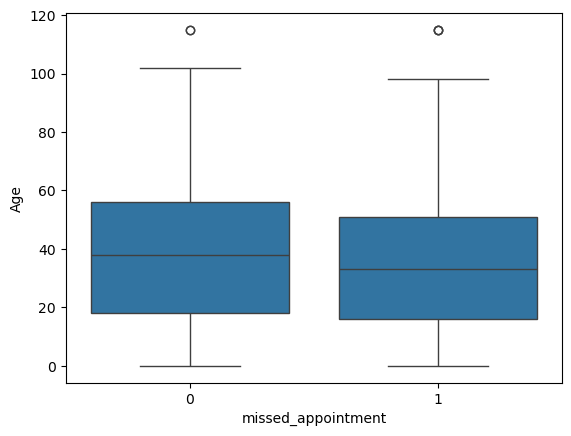

In [31]:
sns.boxplot(
    data=df,
    x="missed_appointment",
    y="Age"
)


**Interpretation**

#### Patients who missed appointments were slightly younger on average than those who attended.

--

### 3.2.2 Gender

#### Gender and Appointment Attendance

Attendance rates were compared between male and female patients to determine whether gender is associated with missed appointments.

In [32]:
calculate_no_show_stats(df, "Gender")

,appointments,missed,missed_rate
Gender,,,
F,71839,14594,0.203149
M,38687,7725,0.199679


#### Gender barplot

<Axes: xlabel='Gender', ylabel='missed_appointment'>

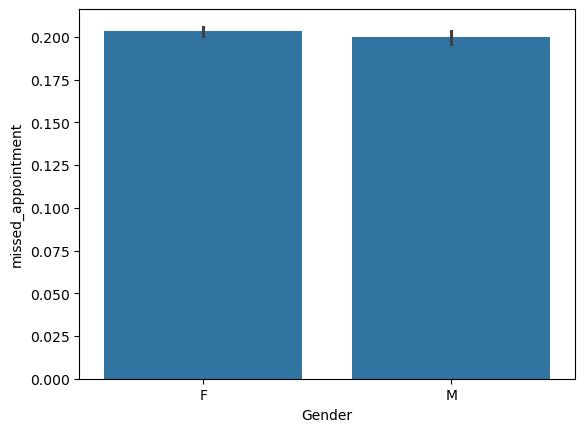

In [33]:
sns.barplot(
    data=df,
    x="Gender",
    y="missed_appointment"
)

**Interpretation**

#### Male and female patients exhibited nearly identical no-show rates, suggesting that gender is not a strong predictor of attendance.

### 3.2.3 Scholarship

#### Scholar ship and Appointment Attendance

Attendance rates were compared between scholarship patients

In [34]:
calculate_no_show_stats(df, "Scholarship")

,appointments,missed,missed_rate
Scholarship,,,
1,10861,2578,0.237363
0,99665,19741,0.198074


#### Scholarship barplot

<Axes: xlabel='Scholarship', ylabel='missed_appointment'>

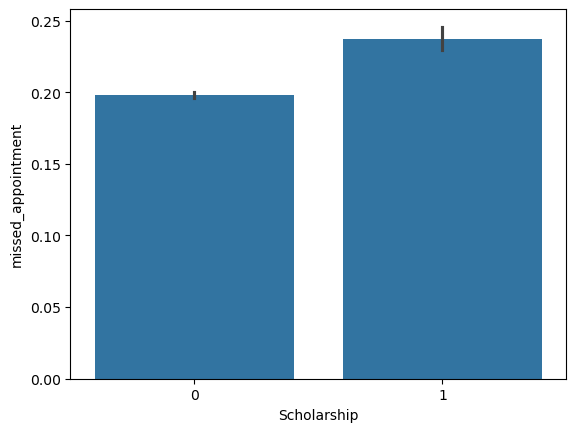

In [35]:
sns.barplot(
    data=df,
    x="Scholarship",
    y="missed_appointment"
)

**Interpretation**
#### It seems that patients with scholarship tends to no-show to appointment, but not significantly

### 3.2.4 Medical Conditions

#### Medical Conditions and Appointment Attendance

Several medical conditions were examined to determine whether patients with chronic conditions exhibit different attendance behavior.

In [36]:
from IPython.display import display

variables = [
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "HasHandicap"
]

for var in variables:

    stats = calculate_no_show_stats(df, var)

    print(f"\n### {var}")
    display(stats)


### Hipertension


,appointments,missed,missed_rate
Hipertension,,,
0,88725,18547,0.209039
1,21801,3772,0.173020



### Diabetes


,appointments,missed,missed_rate
Diabetes,,,
0,102583,20889,0.203630
1,7943,1430,0.180033



### Alcoholism


,appointments,missed,missed_rate
Alcoholism,,,
0,107166,21642,0.201948
1,3360,677,0.201488



### HasHandicap


,appointments,missed,missed_rate
HasHandicap,,,
0,108285,21912,0.202355
1,2241,407,0.181615


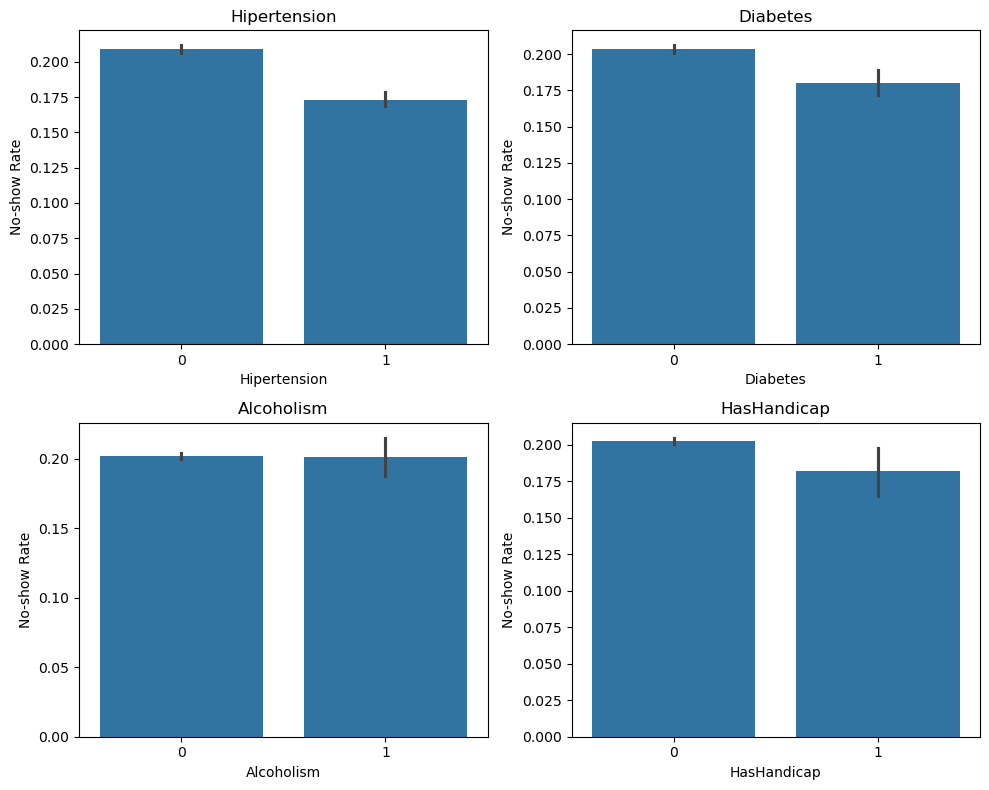

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, var in zip(axes.flatten(), variables):

    sns.barplot(
        data=df,
        x=var,
        y="missed_appointment",
        ax=ax
    )

    ax.set_title(var)
    ax.set_ylabel("No-show Rate")

plt.tight_layout()
plt.show()

**Interpretation**

#### Several medical conditions were analyzed to determine whether patients with chronic conditions exhibit different attendance behavior. Non hipertense patients tends to no-show slightly than not hypertense, the same situation for diabetes. 

## 3.3 Research Question 2:
### How do waiting time, SMS reminders, and neighbourhood relate to attendance?

### 3.3.1 Neighbourhood

#### Neighbourhood and Appointment Attendance

Attendance rates were analyzed across neighbourhoods to identify geographic differences in no-show behavior.

In [38]:
neighbourhood_stats = calculate_no_show_stats(df, "Neighbourhood")
neighbourhood_stats

,appointments,missed,missed_rate
Neighbourhood,,,
ILHAS OCEÂNICAS DE TRINDADE,2,2,1.000000
SANTOS DUMONT,1276,369,0.289185
SANTA CECÍLIA,448,123,0.274554
SANTA CLARA,506,134,0.264822
ITARARÉ,3514,923,0.262664
...,...,...,...
SOLON BORGES,469,69,0.147122
MÁRIO CYPRESTE,371,54,0.145553
AEROPORTO,8,1,0.125000


### see that there are nighbourhoods with 1 or 2 patients that no-shows, thats a rate of 100%, but with a few data it is not significant by itself

### What if we only consider neighbourhoods with more than 100 appointments

In [39]:
neighbourhood_stats = neighbourhood_stats[
    neighbourhood_stats["appointments"] >= 100
]

neighbourhood_stats = neighbourhood_stats.sort_values(
    "missed_rate",
    ascending=False
)

neighbourhood_stats.head(20)

,appointments,missed,missed_rate
Neighbourhood,,,
SANTOS DUMONT,1276,369,0.289185
SANTA CECÍLIA,448,123,0.274554
SANTA CLARA,506,134,0.264822
ITARARÉ,3514,923,0.262664
JESUS DE NAZARETH,2853,696,0.243954
HORTO,175,42,0.240000
ILHA DO PRÍNCIPE,2266,532,0.234775
CARATOÍRA,2565,591,0.230409
ANDORINHAS,2262,521,0.230327


### top15 of no-show neighbourhoods

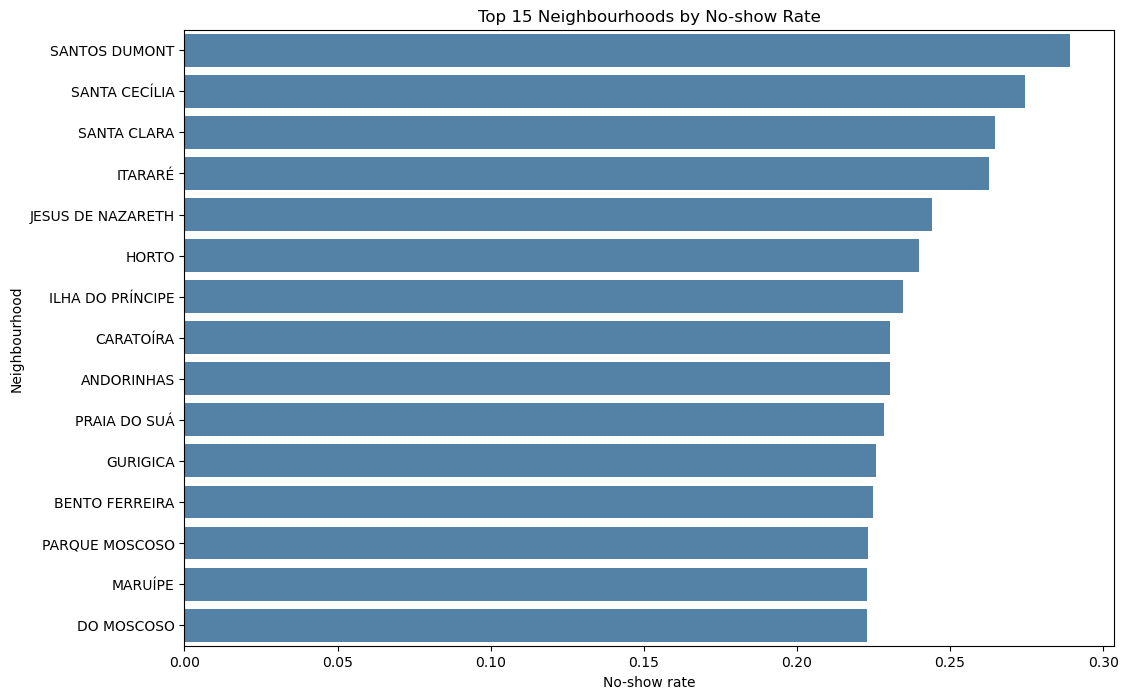

In [40]:
top15 = neighbourhood_stats.head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top15,
    x="missed_rate",
    y=top15.index,
    color="steelblue"
)

plt.xlabel("No-show rate")
plt.ylabel("Neighbourhood")
plt.title("Top 15 Neighbourhoods by No-show Rate")
plt.savefig('neighbourhood_no_show_rate.png',dpi=300)
plt.show()


### Neighbourhood appears to be one of the strongest factors associated with appointment attendance.

### 3.3.2 SMS Reminders

#### SMS Reminders and Appointment Attendance

Patients who received SMS reminders were compared with those who did not.

In [41]:
sms_stats = (
    df.groupby("SMS_received")
      .agg(
          appointments=("missed_appointment", "count"),
          missed=("missed_appointment", "sum"),
          missed_rate=("missed_appointment", "mean")
      )
)

sms_stats

,appointments,missed,missed_rate
SMS_received,,,
0,75044,12535,0.167035
1,35482,9784,0.275745


<Axes: xlabel='SMS_received', ylabel='missed_appointment'>

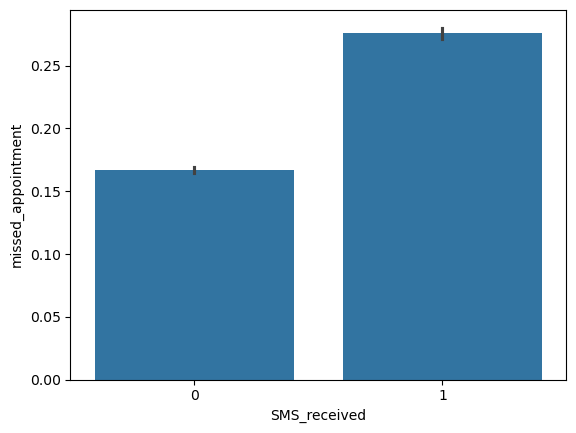

In [42]:
sns.barplot(
    data=df,
    x="SMS_received",
    y="missed_appointment"
)

### See that patients receiving SMS reminders exhibited higher no-show rates than patients who did not receive reminders. why is that?

### SMS Reminders and Attendance

At first glance, patients receiving SMS reminders exhibited higher no-show rates.

However, further analysis revealed that these patients also experienced substantially longer waiting times between scheduling and appointment dates. Therefore, the observed relationship should not be interpreted as evidence that SMS reminders cause missed appointments.

In [56]:
df_clean["WaitingBin"] = pd.cut(
    df_clean["WaitingDays"],
    bins=[0, 7, 14, 30, 60, 180],
    labels=[
        "0-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "60+ days"
    ]
)

sms_waiting_stats = (
    df_clean
    .groupby(["WaitingBin", "SMS_received"])
    ["missed_appointment"]
    .mean()
    .reset_index()
)

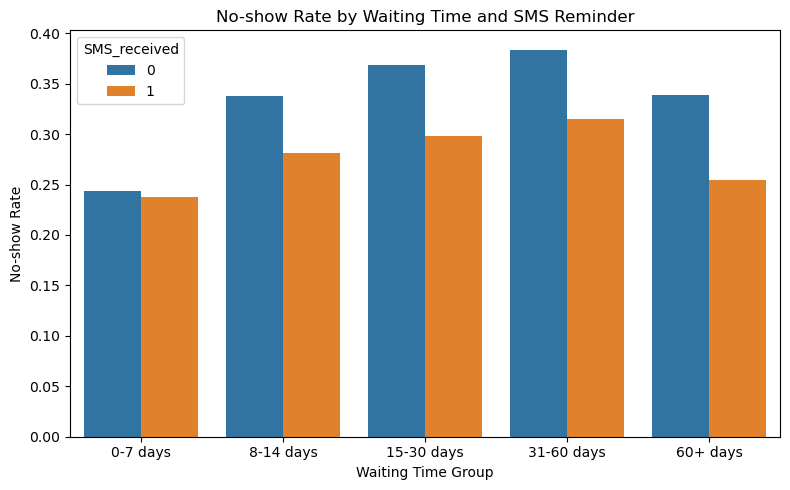

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=sms_waiting_stats,
    x="WaitingBin",
    y="missed_appointment",
    hue="SMS_received"
)

plt.title("No-show Rate by Waiting Time and SMS Reminder")
plt.xlabel("Waiting Time Group")
plt.ylabel("No-show Rate")

plt.tight_layout()

plt.savefig(
    "sms_waiting_bins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.3.3 Waiting Time

#### Waiting Time Analysis

To better understand the SMS reminder results, a waiting-time variable was constructed using the difference between appointment date and scheduling date.

#### Define waitingdays

In [43]:
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize()
    - df["ScheduledDay"].dt.normalize()
).dt.days

#### Lets describe Waiting days by grouping with sms_received 

In [44]:
df.groupby("SMS_received")["WaitingDays"].describe()

,count,mean,std,min,25%,50%,75%,max
SMS_received,,,,,,,,
0,75044.0,6.007449,12.333598,-6.0,0.0,0.0,6.0,179.0
1,35482.0,19.016713,16.978718,3.0,7.0,14.0,27.0,179.0


#### There are a few negative values that we must deal first

In [45]:
df.loc[
    df["WaitingDays"] < 0,
    ["ScheduledDay", "AppointmentDay", "WaitingDays"]
].head(30)

,ScheduledDay,AppointmentDay,WaitingDays
27033,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1
55226,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1
64175,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1
71533,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6
72362,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1


#### Data Quality Issue: Negative Waiting Times

Five observations produced negative waiting times, indicating that the appointment date preceded the scheduling date.

Because this situation is logically impossible and represents less than 0.01% of the dataset, these records were removed from subsequent analyses.

In [46]:
df_clean = df[df["WaitingDays"] >= 0].copy()

#### Lets describe again

In [47]:
df_clean.groupby("SMS_received")["WaitingDays"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

,count,mean,std,min,25%,50%,75%,95%,max
SMS_received,,,,,,,,,
0,75039.0,6.007983,12.333825,0.0,0.0,0.0,6.0,31.0,179.0
1,35482.0,19.016713,16.978718,3.0,7.0,14.0,27.0,55.0,179.0


In [48]:
(df_clean["WaitingDays"] > 100).sum()

np.int64(138)

<Axes: xlabel='WaitingDays', ylabel='Count'>

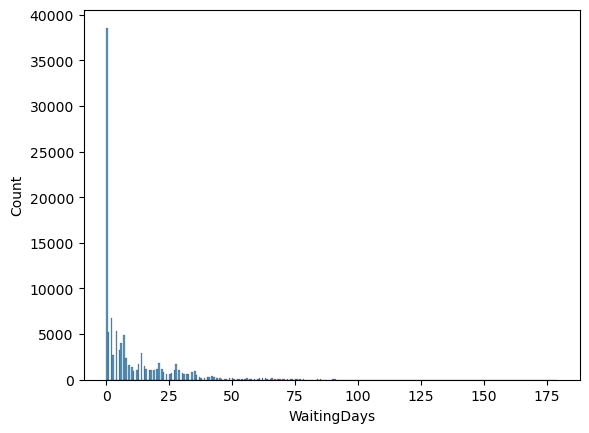

In [51]:
sns.histplot(df_clean["WaitingDays"])

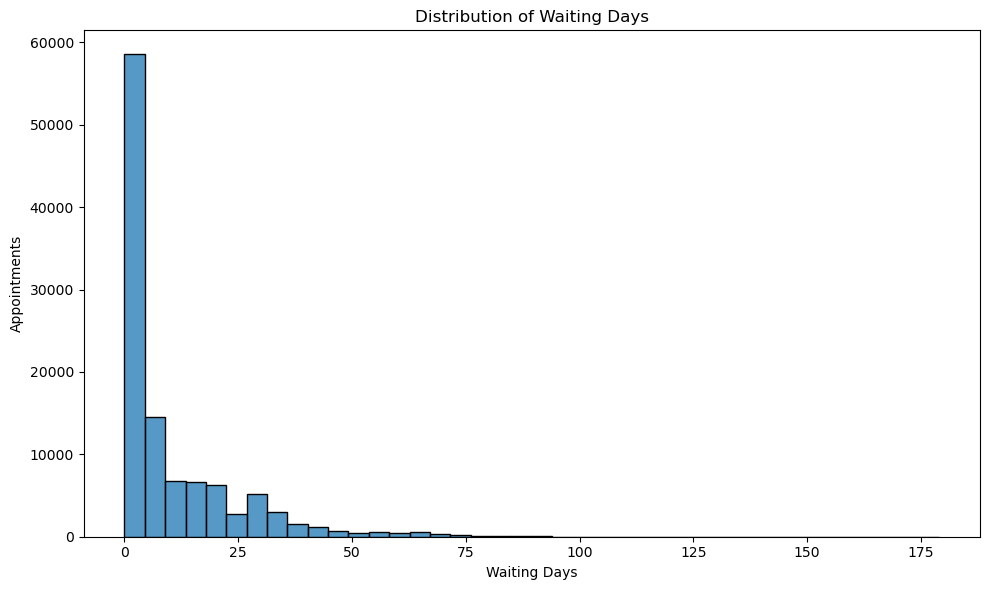

In [52]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["WaitingDays"],
    bins=40
)

plt.title("Distribution of Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Appointments")

plt.tight_layout()

plt.savefig(
    "waiting_days_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

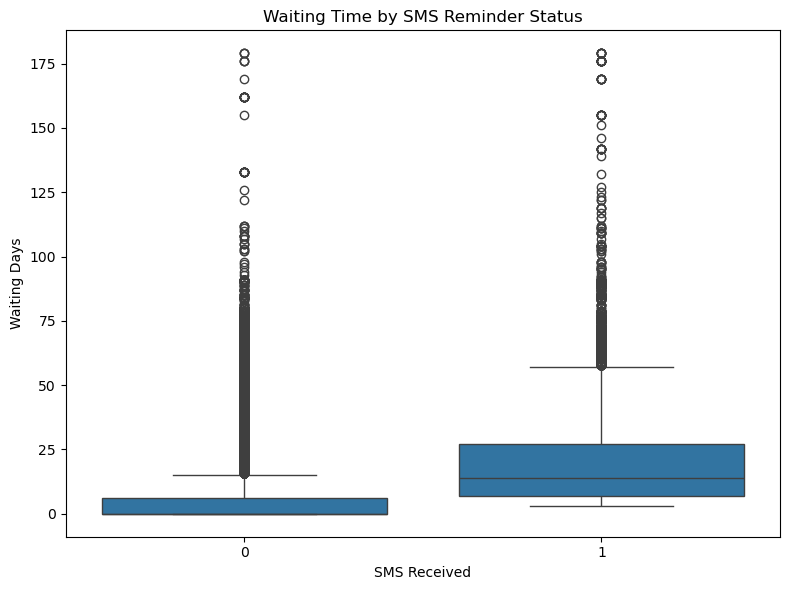

In [54]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x="SMS_received",
    y="WaitingDays"
)

plt.title("Waiting Time by SMS Reminder Status")
plt.xlabel("SMS Received")
plt.ylabel("Waiting Days")

plt.tight_layout()

plt.savefig(
    "sms_waiting_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Extreme Waiting Times

Although waiting times up to 179 days were observed, only 138 appointments (approximately 0.12% of the dataset) exceeded 100 waiting days.

Therefore, extremely long waiting periods exist but represent a very small fraction of all appointments.

In [49]:
df_clean["WaitingDays"].quantile([0.90, 0.95, 0.99, 0.999])

0.900     30.0
0.950     39.0
0.990     68.0
0.999    108.0
Name: WaitingDays, dtype: float64

#### Waiting Time Percentiles

The waiting-time distribution is strongly right-skewed.

- 90% of appointments occurred within 30 days.
- 95% occurred within 39 days.
- 99% occurred within 68 days.
- Only the most extreme 0.1% exceeded 108 days.

This suggests that waiting times longer than 100 days should be considered rare outliers rather than typical appointment experiences.

**Interpretation**
#### Patients who received SMS reminders had substantially longer waiting times. This suggests that waiting time may partially explain the higher no-show rates observed among patients receiving reminders.

### Others: Correlation Map

<Axes: >

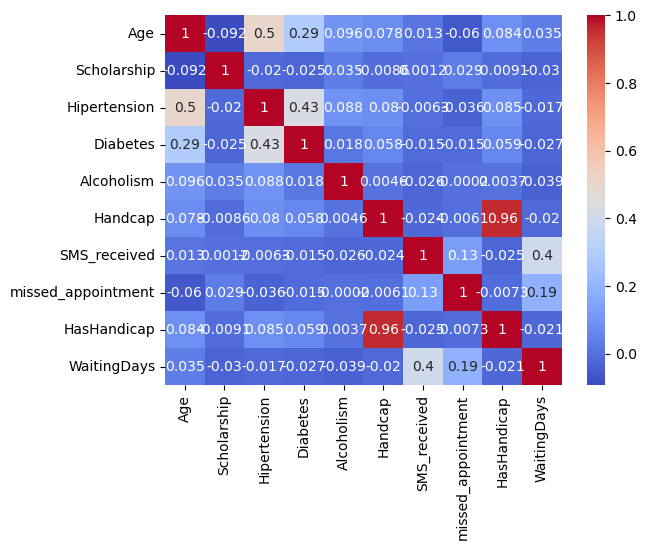

In [50]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

<a id='conclusions'></a>
# 4. Conclusions

## 4.1 Main Findings


The objective of this analysis was to identify factors associated with missed medical appointments in Brazil for no-show appointments dataset (Kaggle).

Demographic, medical, and appointment-related variables were explored to determine their relationship with appointment attendance (no-show variable).


The analysis showed that age had a modest relationship with appointment attendance. Patients who missed appointments tended to be slightly younger than those who attended, although the observed differences were not significant.

Further analysis showed that gender was not strongly associated with missed appointments. Male and female patients exhibited very similar no-show rates, suggesting that gender alone is not a useful predictor of attendance behavior.

Medical conditions such as hypertension, diabetes, alcoholism, and disability status showed only limited differences in no-show rates. Patients without hipertension or diabetes tends slightly to no-show more than hipertense or diabetes patients. However these variables appeared to have weaker associations with appointment attendance than other factors explored in this study. 

In the analysis Neighbourhood was one of the most relevant variables. Considerable differences in no-show rates were observed across neighbourhoods, suggesting that geographic, socioeconomic, or accessibility-related factors may influence attendance appointments behavior.

SMS reminders initially appeared to be associated with higher no-show rates. However, further investigation revealed that patients receiving SMS reminders also experienced significant longer waiting times. This finding suggests that waiting time may partially explain the observed relationship between SMS reminders and appointment attendance.

The analysis of waiting times revealed that patients receiving SMS reminders waited considerably longer between scheduling and appointment dates. Therefore, SMS reminders should not be interpreted as causing missed appointments. Instead, they appear to be associated with appointment lead time.


## 4.2  Limitations

This investigation is based on exploratory data analysis and does not establish causal relationships between variables. No statistical hypothesis testing or predictive modeling was performed as could be Machine Learning or statistics. Other important factors, as transportation access, income level, appointment type, and healthcare facility characteristics, were not available in the dataset.

For future work the analysis could involve predictive modeling techniques (ML) and multivariate analyses to better understand the relative importance of each factor and identify patients at higher risk of missing appointments.


# Running this cell will execute a bash command to convert this notebook to an .html file
#!python -m nbconvert --to html Investigate_a_Dataset.ipynb